# Notebook 2 — Convergence des intégrateurs numériques

**Deux études complémentaires :**

### Étude A : Euler vs Verlet — système RSF stick-slip
Montre que la discontinuité stick→slip bride les deux schémas à O(dt), 
même si Verlet est O(dt²) sur les phases lisses.

### Étude B : RK45 vs Verlet — oscillateur harmonique lisse
Sur une ODE lisse avec solution analytique exacte, on vérifie les ordres 
théoriques (Euler O(dt), Verlet O(dt²)) et compare l'efficacité RK45 vs Verlet.

Référence : Erickson et al. (2011)


# Code 2 — Convergence Euler vs Verlet : rôle de la discontinuité stick→slip

**Objectif** : montrer pourquoi Verlet ne récupère pas son ordre O(dt²) en présence d'une discontinuité stick→slip.

**Stratégie** : deux panneaux côte-à-côte avec deux références différentes.

| Panneau | Modèle | Référence | Résultat attendu |
|---------|--------|-----------|------------------|
| A | RSF Scholz stick-slip (discontinuité) | Euler fin dt=1e-6 (même physique discrète) | Euler ~O(dt), Verlet ~O(dt) |
| B | Oscillateur harmonique lisse | Solution analytique exacte (pas de plancher) | Euler ~O(dt), Verlet ~O(dt²) |

> **Message** : la discontinuité stick→slip bloque *les deux schémas* à O(dt). Sur une ODE lisse, Verlet retrouve son ordre théorique O(dt²).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Parameters modèle A (RSF stick-slip) ───────────────────────────────────
mu0 = 0.6; a = 0.01; b = 0.015; v0 = 1e-6; Dc = 1e-5
sigma_n = 9.81; m = 1.0; k = 1000; v_load = 0.001; duration = 20

# ── Parameters modèle B (harmonic oscillator) ───────────────────────────
k_osc = 100.0; g = 9.81; x_nat = 0.0
x_eq  = x_nat + m*g/k_osc
x0    = x_eq - 0.10
v0_osc = 0.0
omega  = np.sqrt(k_osc/m)
A_amp  = x0 - x_eq
T_sim  = 2*np.pi/omega * 2.7

def exact_osc(t):
    """Solution analytique exacte de l'harmonic oscillator."""
    return x_eq + A_amp*np.cos(omega*t)

## Modèle A — RSF Scholz avec discontinuité stick→slip

À chaque déclenchement de glissement, la vitesse est initialisée à une valeur finie (`v = 1e-8 m/s`).
Cette **discontinuité** introduit une erreur de saut O(1) par événement, indépendante de dt.
Elle limite les deux schémas à O(dt) global, quel que soit l'ordre du schéma sur les phases lisses.


In [2]:
def rsf_euler_A(dt):
    """Euler explicite — RSF Scholz avec seuil stick/slip."""
    t = np.arange(0, duration+dt, dt); n = len(t)
    x = np.zeros(n); v = np.zeros(n); th = np.zeros(n)
    stick = np.ones(n, bool); th[0] = Dc/v0
    for i in range(1, n):
        Fs = k*(v_load*t[i] - x[i-1])
        if stick[i-1]:
            mu_st = mu0 + b*np.log(th[i-1]*v0/Dc)
            if abs(Fs) > mu_st*sigma_n:
                stick[i]=False; v[i]=1e-8; x[i]=x[i-1]; th[i]=Dc/1e-8
            else:
                x[i]=x[i-1]; th[i]=th[i-1]+dt
        else:
            vv = max(v[i-1], 1e-12)
            mu = mu0 + a*np.log(1+vv/v0) + b*np.log(th[i-1]*v0/Dc)
            Ff = mu*sigma_n*np.sign(v[i-1])
            acc = (Fs-Ff)/m
            v[i] = v[i-1]+acc*dt;  x[i] = x[i-1]+v[i-1]*dt
            th[i] = th[i-1] + (1 - v[i-1]*th[i-1]/Dc)*dt
            if abs(v[i]) <= 1e-10:
                v[i]=0.; stick[i]=True; th[i]=th[i-1]
    return t, x


def rsf_verlet_A(dt):
    """Velocity Verlet — RSF Scholz avec seuil stick/slip."""
    t = np.arange(0, duration+dt, dt); n = len(t)
    x = np.zeros(n); v = np.zeros(n); th = np.zeros(n)
    stick = np.ones(n, bool); th[0] = Dc/v0

    def ff(vv, th_):
        ve = max(abs(vv), 1e-12)
        mu = mu0 + a*np.log(1+ve/v0) + b*np.log(th_*v0/Dc)
        return mu*sigma_n*(1. if vv >= 0 else -1.)

    for i in range(1, n):
        if stick[i-1]:
            Fs = k*(v_load*t[i] - x[i-1])
            mu_st = mu0 + b*np.log(th[i-1]*v0/Dc)
            if abs(Fs) > mu_st*sigma_n:
                stick[i]=False; v[i]=1e-8; x[i]=x[i-1]; th[i]=Dc/1e-8
            else:
                x[i]=x[i-1]; th[i]=th[i-1]+dt
        else:
            Fs_o = k*(v_load*t[i-1]-x[i-1]);  Ff_o = ff(v[i-1], th[i-1])
            ao   = (Fs_o - Ff_o)/m
            x[i]  = x[i-1] + v[i-1]*dt + 0.5*ao*dt**2
            th[i] = th[i-1] + (1 - v[i-1]*th[i-1]/Dc)*dt
            Fs_n  = k*(v_load*t[i]-x[i]);  vh = v[i-1]+0.5*ao*dt;  Ff_n = ff(vh, th[i])
            an    = (Fs_n - Ff_n)/m
            v[i]  = v[i-1] + 0.5*(ao+an)*dt
            if abs(v[i]) <= 1e-10:
                v[i]=0.; stick[i]=True; th[i]=th[i-1]
    return t, x


## Modèle B — Oscillateur harmonique lisse

ODE entièrement lisse, solution analytique exacte disponible → pas de plancher de référence.
Permet de vérifier les ordres théoriques : Euler O(dt), Verlet O(dt²).


In [3]:
def osc_euler(dt):
    """Euler explicite — harmonic oscillator."""
    t = np.arange(0, T_sim+0.5*dt, dt); n = len(t)
    x = np.zeros(n); v = np.zeros(n)
    x[0]=x0; v[0]=v0_osc
    o2 = k_osc/m;  F0 = g + o2*x_nat
    for i in range(1, n):
        ac = F0 - o2*x[i-1]
        v[i] = v[i-1]+ac*dt;  x[i] = x[i-1]+v[i-1]*dt
    return t, x


def osc_verlet(dt):
    """Velocity Verlet — harmonic oscillator."""
    t = np.arange(0, T_sim+0.5*dt, dt); n = len(t)
    x = np.zeros(n); v = np.zeros(n)
    x[0]=x0; v[0]=v0_osc
    o2 = k_osc/m;  F0 = g + o2*x_nat
    for i in range(1, n):
        ac = F0 - o2*x[i-1]
        vh = v[i-1]+0.5*ac*dt;  x[i] = x[i-1]+vh*dt
        an = F0 - o2*x[i];      v[i] = vh+0.5*an*dt
    return t, x

## Calcul des références et balayage en dt

- **Référence A** : Euler dt=1e-6, même modèle RSF stick-slip (physique discrète identique).
- **Référence B** : solution analytique exacte de l'oscillateur (pas d'erreur de référence).


In [4]:
# ── Reference A : Euler dt=1e-6 ────────────────────────────────────────────
print("Calcul reference A (Euler dt=1e-6, stick-slip) — ~20M points...")
t_rA, x_rA = rsf_euler_A(1e-6)
print(f"  {len(t_rA):,} points computed")

# ── Balayage dt modèle A ───────────────────────────────────────────────────
dt_A = np.array([5e-4, 2e-4, 1e-4, 5e-5, 2e-5, 1e-5])

print("\nBalayage A (stick-slip)...")
eA = []; vA = []
for dt in dt_A:
    te, xe = rsf_euler_A(dt)
    tv, xv = rsf_verlet_A(dt)
    eA.append(np.sqrt(np.mean((xe - np.interp(te, t_rA, x_rA))**2)))
    vA.append(np.sqrt(np.mean((xv - np.interp(tv, t_rA, x_rA))**2)))
    print(f"  dt={dt:.0e}  Euler={eA[-1]:.2e}  Verlet={vA[-1]:.2e}")
eA = np.array(eA);  vA = np.array(vA)

# ── Balayage dt modèle B ───────────────────────────────────────────────────
dt_B = np.geomspace(1e-5, 5e-3, 15)

print("\nBalayage B (oscillateur)...")
eB = []; vB = []
for dt in dt_B:
    te, xe = osc_euler(dt);   eB.append(np.sqrt(np.mean((xe - exact_osc(te))**2)))
    tv, xv = osc_verlet(dt);  vB.append(np.sqrt(np.mean((xv - exact_osc(tv))**2)))
eB = np.array(eB);  vB = np.array(vB)

# ── Régressions ────────────────────────────────────────────────────────────
def fit(dt, err, mask=None):
    if mask is None: mask = (err > 1e-13) & np.isfinite(err)
    if mask.sum() < 3: return np.nan
    return stats.linregress(np.log10(dt[mask]), np.log10(err[mask]))[0]

rAe = fit(dt_A, eA)
rAv = fit(dt_A, vA)
maskB = (eB > 1e-13) & (dt_B > 1e-6)
rBe = fit(dt_B, eB, maskB)
rBv = fit(dt_B, vB, maskB)

print(f"\nA (stick-slip, ref Euler 1e-6) : Euler = {rAe:.2f}, Verlet = {rAv:.2f}")
print(f"B (oscillateur, ref exacte)     : Euler = {rBe:.2f}, Verlet = {rBv:.2f}")

Calcul référence A (Euler dt=1e-6, stick-slip) — ~20M points...
  20,000,002 points calculés

Balayage A (stick-slip)...
  dt=5e-04  Euler=4.27e-12  Verlet=2.74e-03
  dt=2e-04  Euler=1.87e-12  Verlet=1.39e-03
  dt=1e-04  Euler=8.16e-13  Verlet=7.55e-04
  dt=5e-05  Euler=4.82e-13  Verlet=3.95e-04
  dt=2e-05  Euler=1.26e-13  Verlet=1.62e-04
  dt=1e-05  Euler=5.92e-14  Verlet=8.19e-05

Balayage B (oscillateur)...

A (stick-slip, ref Euler 1e-6) : Euler = 1.08, Verlet = 0.91
B (oscillateur, ref exacte)     : Euler = 1.02, Verlet = 2.00


## Figure — Comparaison des ordres de convergence


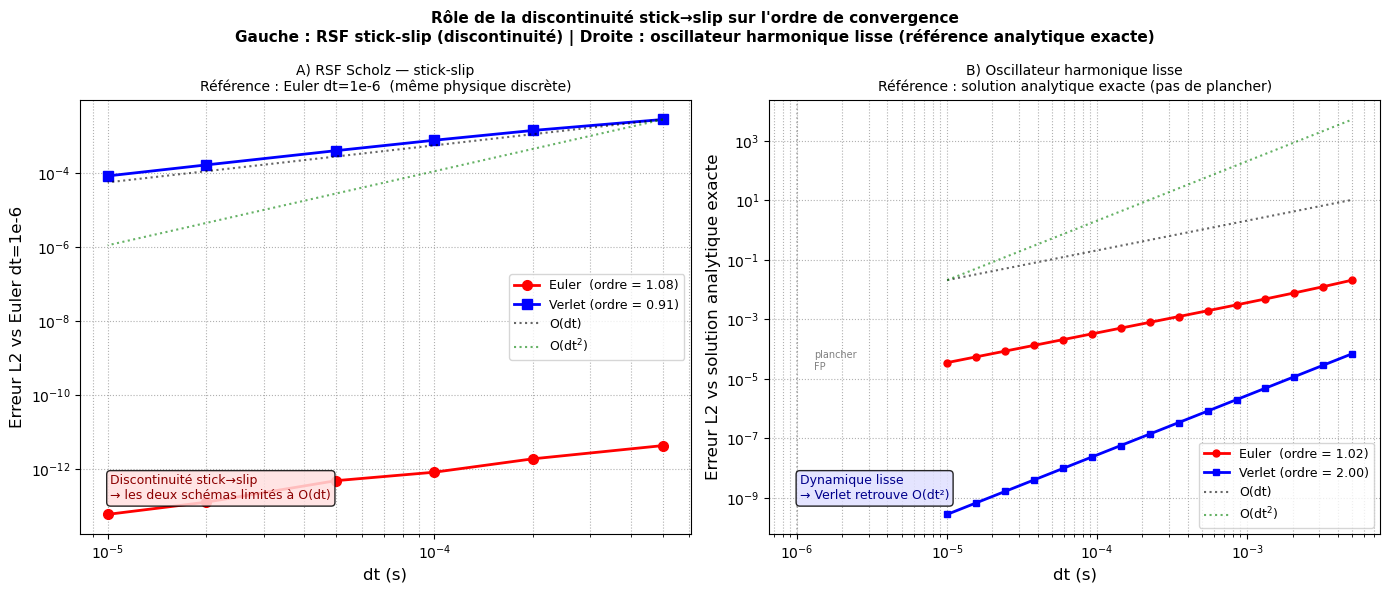

Sauvegardé : code2_v3_final.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Effect of the stick→slip discontinuity on'convergence order\n"
    "Left: RSF stick-slip (discontinuity) | "
    "Droite : harmonic oscillator lisse (reference analytique exacte)",
    fontsize=11, fontweight='bold')

# ── Panneau A : stick-slip ──────────────────────────────────────────────────
ax = axes[0]
ax.loglog(dt_A, eA, 'o-', color='red',  lw=2, ms=7, label=f'Euler  (ordre = {rAe:.2f})')
ax.loglog(dt_A, vA, 's-', color='blue', lw=2, ms=7, label=f'Verlet (ordre = {rAv:.2f})')
ref0 = max(eA.max(), vA.max())
ax.loglog(dt_A, ref0*(dt_A/dt_A[0]),    'k:', lw=1.5, alpha=0.6, label='O(dt)')
ax.loglog(dt_A, ref0*(dt_A/dt_A[0])**2, 'g:', lw=1.5, alpha=0.6, label=r'O(dt$^2$)')
ax.set_xlabel('dt (s)', fontsize=12)
ax.set_ylabel('Erreur L2 vs Euler dt=1e-6', fontsize=12)
ax.set_title('A) RSF Scholz — stick-slip\n'
             'Reference : Euler dt=1e-6  (même physique discrète)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, which='both', ls=':')
ax.text(0.05, 0.08,
        "Discontinuité stick→slip\n→ les deux schémas limités à O(dt)",
        transform=ax.transAxes, fontsize=9, color='darkred',
        bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.85))

# ── Panneau B : oscillateur ─────────────────────────────────────────────────
ax = axes[1]
ax.loglog(dt_B, eB, 'o-', color='red',  lw=2, ms=5, label=f'Euler  (ordre = {rBe:.2f})')
ax.loglog(dt_B, vB, 's-', color='blue', lw=2, ms=5, label=f'Verlet (ordre = {rBv:.2f})')
ref0B = max(eB[maskB].max(), vB[maskB].max())
ax.loglog(dt_B[maskB], ref0B*(dt_B[maskB]/dt_B[maskB][0]),    'k:', lw=1.5, alpha=0.6, label='O(dt)')
ax.loglog(dt_B[maskB], ref0B*(dt_B[maskB]/dt_B[maskB][0])**2, 'g:', lw=1.5, alpha=0.6, label=r'O(dt$^2$)')
ax.axvline(1e-6, color='gray', ls=':', lw=1.2, alpha=0.6)
ax.text(1.3e-6, eB.min()*0.5, 'plancher\nFP', fontsize=7, color='gray', va='bottom')
ax.set_xlabel('dt (s)', fontsize=12)
ax.set_ylabel('Erreur L2 vs solution analytique exacte', fontsize=12)
ax.set_title('B) Harmonic oscillator lisse\n'
             'Reference : solution analytique exacte (pas de plancher)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, which='both', ls=':')
ax.text(0.05, 0.08,
        "Dynamique lisse\n→ Verlet retrouve O(dt²)",
        transform=ax.transAxes, fontsize=9, color='darkblue',
        bbox=dict(boxstyle='round', facecolor='#e0e0ff', alpha=0.85))

plt.tight_layout()
plt.savefig('code2_v3_final.png', dpi=150)
plt.show()
print("Saved: code2_v3_final.png")

---
## Étude B — RK45 adaptatif vs Verlet sur oscillateur harmonique

Sur une ODE **lisse** (pas de discontinuité), on compare :
- Verlet (symplectique, O(dt²)) : erreur vs dt
- RK45 adaptatif : erreur vs tolérance
- Efficacité : erreur vs nombre d'évaluations de la fonction


In [6]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy import stats
import gc
import os

# ═══════════════════════════════════════════════════════════════════════════
#  RK45 INTEGRATOR (shared by all codes)
# ═══════════════════════════════════════════════════════════════════════════

_A_tab = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [1/5, 0, 0, 0, 0, 0, 0],
    [3/40, 9/40, 0, 0, 0, 0, 0],
    [44/45, -56/15, 32/9, 0, 0, 0, 0],
    [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0, 0],
    [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0, 0],
    [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0],
])
_B5 = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0])
_B4 = np.array([5179/57600, 0, 7571/16695, 393/640, -92097/339200, 187/2100, 1/40])
_C  = np.array([0, 1/5, 3/10, 4/5, 8/9, 1, 1])

def rk45_step(f, t, y, h):
    K = np.zeros((7, len(y)))
    K[0] = f(t, y)
    for i in range(1, 7):
        yi = y + h * np.dot(_A_tab[i, :i], K[:i])
        K[i] = f(t + _C[i] * h, yi)
    y5 = y + h * np.dot(_B5, K)
    y4 = y + h * np.dot(_B4, K)
    return y5, np.abs(y5 - y4)

def rk45_integrate(f, t_span, y0, rtol=1e-8, atol=1e-10,
                   h_init=1e-3, h_min=1e-12, h_max=10.0,
                   max_steps=2_000_000):
    t0, tf = t_span
    y = np.array(y0, dtype=float)
    t = t0
    h = min(h_init, tf - t0)
    chunk = 100_000
    t_list = np.zeros(chunk)
    y_list = np.zeros((chunk, len(y)))
    t_list[0] = t; y_list[0] = y
    idx = 1; n_alloc = chunk; safety = 0.9; n_steps = 0; n_reject = 0

    while t < tf:
        if n_steps >= max_steps:
            print(f"  WARNING: hit max_steps={max_steps:,}"); break
        h = min(h, tf - t)
        h = max(h, h_min)
        y_new, err = rk45_step(f, t, y, h)
        scale = atol + rtol * np.maximum(np.abs(y), np.abs(y_new))
        err_norm = np.sqrt(np.mean((err / scale)**2))
        if err_norm <= 1.0:
            t += h; y = y_new; n_steps += 1
            if idx >= n_alloc:
                t_list = np.concatenate([t_list, np.zeros(chunk)])
                y_list = np.concatenate([y_list, np.zeros((chunk, len(y)))])
                n_alloc += chunk
            t_list[idx] = t; y_list[idx] = y; idx += 1
            h *= (5.0 if err_norm < 1e-30 else safety * err_norm**(-0.2))
            h = min(h, h_max)
        else:
            h *= safety * err_norm**(-0.25)
            h = max(h, h_min); n_reject += 1
    print(f"  {idx:,} steps ({n_reject:,} rejected)")
    return t_list[:idx], y_list[:idx]

# ═══════════════════════════════════════════════════════════════════════════
#  SHARED MODELS
# ═══════════════════════════════════════════════════════════════════════════

def coulomb_sigma_n(mu_s, mu_d, sigma_n, m, k, v_load, dt, duration):
    timesteps = np.arange(0, duration + dt, dt)
    n = len(timesteps)
    x = np.zeros(n); v = np.zeros(n)
    Fs = np.zeros(n); Ff = np.zeros(n)
    stick = np.ones(n, dtype=bool)
    for i in range(1, n):
        x_load = v_load * timesteps[i]
        Fs[i] = k * (x_load - x[i-1])
        if stick[i-1]:
            Fmax = mu_s * sigma_n
            Ff[i] = np.clip(Fs[i], -Fmax, Fmax)
            if Fs[i] > Fmax:
                stick[i] = False; v[i] = 1e-8; x[i] = x[i-1]
                Ff[i] = mu_d * sigma_n
            else:
                x[i] = x[i-1]
        else:
            if v[i-1] <= 0:
                v[i] = 0.0; stick[i] = True; x[i] = x[i-1]
            else:
                Ff[i] = mu_d * sigma_n
                a = (Fs[i] - Ff[i]) / m
                v[i] = v[i-1] + a * dt
                x[i] = x[i-1] + v[i-1] * dt + 0.5 * a * dt**2
                if v[i] <= 0: v[i] = 0.0; stick[i] = True
    return timesteps, x, v, Fs, Ff


def rsf_scholz_euler(mu0, a, b, v0, Dc, sigma_n, m, k, v_load, dt, duration):
    timesteps = np.arange(0, duration + dt, dt)
    n = len(timesteps)
    x = np.zeros(n); v = np.zeros(n); theta = np.zeros(n)
    Fs = np.zeros(n); Ff = np.zeros(n)
    stick = np.ones(n, dtype=bool); theta[0] = Dc / v0
    for i in range(1, n):
        x_load = v_load * timesteps[i]
        Fs[i] = k * (x_load - x[i-1])
        if stick[i-1]:
            mu_st = mu0 + b * np.log(theta[i-1] * v0 / Dc)
            Fmax = mu_st * sigma_n
            Ff[i] = np.clip(Fs[i], -Fmax, Fmax)
            if np.abs(Fs[i]) > Fmax:
                stick[i] = False; v[i] = 1e-8; x[i] = x[i-1]
                theta[i] = Dc / 1e-8
            else:
                x[i] = x[i-1]; theta[i] = theta[i-1] + dt
        else:
            vv = max(v[i-1], 1e-12)
            mu = mu0 + a * np.log(1 + vv/v0) + b * np.log(theta[i-1]*v0/Dc)
            Ff[i] = mu * sigma_n * np.sign(v[i-1])
            acc = (Fs[i] - Ff[i]) / m
            v[i] = v[i-1] + acc * dt
            x[i] = x[i-1] + v[i-1] * dt
            theta[i] = theta[i-1] + (1 - v[i-1]*theta[i-1]/Dc) * dt
            if np.abs(v[i]) <= 1e-10:
                v[i] = 0.0; stick[i] = True; theta[i] = theta[i-1]
    return timesteps, x, v, Fs, Ff, theta


def rsf_scholz_verlet(mu0, a, b, v0, Dc, sigma_n, m, k, v_load, dt, duration):
    timesteps = np.arange(0, duration + dt, dt)
    n = len(timesteps)
    x = np.zeros(n); v = np.zeros(n); theta = np.zeros(n)
    Fs = np.zeros(n); Ff = np.zeros(n)
    stick = np.ones(n, dtype=bool); theta[0] = Dc / v0

    def fric_force(vv, th):
        ve = max(abs(vv), 1e-12)
        mu = mu0 + a*np.log(1+ve/v0) + b*np.log(th*v0/Dc)
        return mu * sigma_n * (1.0 if vv >= 0 else -1.0)

    for i in range(1, n):
        x_load = v_load * timesteps[i]
        if stick[i-1]:
            Fs[i] = k * (x_load - x[i-1])
            mu_st = mu0 + b * np.log(theta[i-1]*v0/Dc)
            Fmax = mu_st * sigma_n
            Ff[i] = np.clip(Fs[i], -Fmax, Fmax)
            if np.abs(Fs[i]) > Fmax:
                stick[i] = False; v[i] = 1e-8; x[i] = x[i-1]
                theta[i] = Dc / 1e-8
            else:
                x[i] = x[i-1]; theta[i] = theta[i-1] + dt
        else:
            Fs_old = k * (v_load * timesteps[i-1] - x[i-1])
            Ff_old = fric_force(v[i-1], theta[i-1])
            a_old = (Fs_old - Ff_old) / m
            x[i] = x[i-1] + v[i-1]*dt + 0.5*a_old*dt**2
            theta[i] = theta[i-1] + (1 - v[i-1]*theta[i-1]/Dc)*dt
            Fs_new = k * (v_load * timesteps[i] - x[i])
            v_half = v[i-1] + 0.5*a_old*dt
            Ff_new = fric_force(v_half, theta[i])
            a_new = (Fs_new - Ff_new) / m
            v[i] = v[i-1] + 0.5*(a_old + a_new)*dt
            Fs[i] = Fs_new; Ff[i] = Ff_new
            if np.abs(v[i]) <= 1e-10:
                v[i] = 0.0; stick[i] = True; theta[i] = theta[i-1]
    return timesteps, x, v, Fs, Ff, theta


def make_rhs_sigma_n(mu0, a, b, v0, v_slider, Dc, M, k, sigma_n):
    def rhs(t, y):
        u, vel, Theta = y
        v_safe = np.sign(vel)*max(abs(vel), 1e-30)
        ln_v = np.log(abs(v_safe)/v0)
        du     = vel - v_slider
        dv     = (-1.0/M)*(k*u + sigma_n*(mu0 + Theta + a*ln_v))
        dTheta = -(v_safe/Dc)*(Theta + b*ln_v)
        return np.array([du, dv, dTheta])
    return rhs

def simulate_rk45_sigma_n(mu0, a, b, v0, v_slider, Dc, M, k, sigma_n,
                          duration, rtol=1e-8, atol=1e-10, h_max=1.0):
    rhs = make_rhs_sigma_n(mu0, a, b, v0, v_slider, Dc, M, k, sigma_n)
    u0 = -sigma_n*mu0/k + Dc
    t, y = rk45_integrate(rhs, [0, duration], [u0, v0, 0.0],
                          rtol=rtol, atol=atol, h_max=h_max)
    x_block = y[:,0] + v_slider*t
    theta = (Dc/v0)*np.exp(y[:,2]/b)
    return t, x_block, y[:,1], theta

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CODE 3 : RK45 vs Verlet — oscillateur simple                               ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def run_code3():
    print("="*70)
    print("  CODE 3 : RK45 vs Verlet — oscillateur simple")
    print("="*70)

    m,k,g = 1.0, 100.0, 9.81
    x_nat = 0.0; x_eq = x_nat + m*g/k
    x0 = x_eq - 0.10; v0 = 0.0
    T_sim = 2*np.pi*np.sqrt(m/k)*2.7
    omega = np.sqrt(k/m)
    A_amp = x0 - x_eq

    def exact(t): return x_eq + A_amp*np.cos(omega*t)

    def run_verlet(dt):
        t = np.arange(0, T_sim + 0.5*dt, dt)
        n = len(t); x = np.zeros(n); v = np.zeros(n)
        x[0] = x0; v[0] = v0
        o2 = k/m; F0 = g + o2*x_nat
        for i in range(1, n):
            ac = F0 - o2*x[i-1]
            vh = v[i-1] + 0.5*ac*dt
            x[i] = x[i-1] + vh*dt
            an = F0 - o2*x[i]
            v[i] = vh + 0.5*an*dt
        return t, x

    def osc_rhs(t, y):
        return np.array([y[1], g - (k/m)*(y[0]-x_nat)])

    def run_rk45(rtol, atol):
        t, y = rk45_integrate(osc_rhs, [0,T_sim], [x0,v0],
                              rtol=rtol, atol=atol, h_init=1e-3, h_max=T_sim/10)
        return t, y[:,0], len(t)

    dt_vals = np.geomspace(1e-5, 5e-3, 15)
    err_v = []; nsteps_v = []
    print("  Verlet sweep...")
    for dt in dt_vals:
        tv, xv = run_verlet(dt)
        err_v.append(np.sqrt(np.mean((xv - exact(tv))**2)))
        nsteps_v.append(len(tv))
    err_v = np.array(err_v); nsteps_v = np.array(nsteps_v)

    tol_vals = np.geomspace(1e-13, 1e-4, 12)
    err_r = []; nsteps_r = []
    print("  RK45 sweep...")
    for tol in tol_vals:
        tr, xr, ns = run_rk45(tol, tol*0.01)
        err_r.append(np.sqrt(np.mean((xr - exact(tr))**2)))
        nsteps_r.append(ns)
    err_r = np.array(err_r); nsteps_r = np.array(nsteps_r)

    mask = (err_v > 1e-13) & (dt_vals < 2e-3)
    rate_v = stats.linregress(np.log10(dt_vals[mask]), np.log10(err_v[mask]))[0] if np.sum(mask)>2 else np.nan
    print(f"\n  Verlet rate: {rate_v:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax = axes[0]
    ax.loglog(dt_vals, err_v, 'o-', color='blue', label=f'Verlet (rate={rate_v:.2f})')
    if np.sum(mask) > 0:
        ref = err_v[mask][0] / dt_vals[mask][0]**2 * dt_vals[mask]**2
        ax.loglog(dt_vals[mask], ref, 'b:', lw=1, alpha=0.5, label=r'O(dt$^2$)')
    ax.set_xlabel('Verlet dt (s)', color='blue'); ax.set_ylabel('L2 error vs exact')
    ax2 = ax.twiny()
    ax2.loglog(tol_vals, err_r, 's-', color='red', label='RK45')
    ax2.set_xlabel('RK45 tolerance', color='red')
    ax2.tick_params(axis='x', labelcolor='red')
    ax.set_title('Error vs control parameter')
    ax.legend(loc='upper left'); ax2.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    ax = axes[1]
    fevals_v = 2 * nsteps_v
    fevals_r = 7 * nsteps_r
    ax.loglog(fevals_v, err_v, 'o-', color='blue', label='Verlet')
    ax.loglog(fevals_r, err_r, 's-', color='red', label='RK45')
    ax.set_xlabel('Function evaluations'); ax.set_ylabel('L2 error vs exact')
    ax.set_title('Efficiency: error vs cost')
    ax.legend(); ax.grid(True, which='both', ls=':')

    plt.tight_layout()
    plt.savefig('code3_rk45_oscillator.png', dpi=150)
    plt.close(fig); gc.collect()
    print("  Done. (Saved: code3_rk45_oscillator.png)\n")
run_code3()

  CODE 3 : RK45 vs Verlet — oscillateur simple
  Verlet sweep...
  RK45 sweep...
  1,957 steps (1 rejected)
  1,342 steps (1 rejected)
  920 steps (2 rejected)
  630 steps (3 rejected)
  432 steps (4 rejected)
  297 steps (5 rejected)
  203 steps (7 rejected)
  139 steps (5 rejected)
  96 steps (6 rejected)
  66 steps (8 rejected)
  46 steps (6 rejected)
  32 steps (6 rejected)

  Verlet rate: 2.000
  Done. (Saved: code3_rk45_oscillator.png)

